# HealthPulse (Longitudinal Biomarker Trend Dashboard)


**Dataset:** Synthetic longitudinal data grounded in published clinical reference ranges.  
As no public longitudinal urine wellness dataset exists

In [18]:
!pip install scikit-learn pandas numpy scipy matplotlib seaborn joblib -q
print('✓ All packages installed')

✓ All packages installed


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

os.makedirs('models', exist_ok=True)
os.makedirs('charts', exist_ok=True)
print('✓ Imports done')

✓ Imports done


In [20]:
def generate_cohort(n_users=500, n_months=12):
    records = []
    conditions = {
        'healthy':           0.45,
        'early_ckd':         0.15,
        'moderate_ckd':      0.08,   # NEW: caught at later stage
        'uti_episode':       0.14,
        'diabetic_risk':     0.10,   # FIXED: aggressive drift
        'ckd_plus_diabetes': 0.08    # NEW: mixed condition
    }

    for uid in range(n_users):
        condition = np.random.choice(list(conditions.keys()), p=list(conditions.values()))
        age    = np.random.randint(25, 70)
        gender = np.random.choice(['M', 'F'])

        # Moderate CKD users start with already-elevated albumin (caught late)
        if condition == 'moderate_ckd':
            base_cr  = np.random.lognormal(np.log(80),  0.3)
            base_alb = np.random.lognormal(np.log(80),  0.4)   # already elevated
            base_glu = np.random.lognormal(np.log(0.8), 0.3)
        else:
            base_cr  = np.random.lognormal(np.log(120), 0.4)
            base_alb = np.random.lognormal(np.log(5),   0.5)
            base_glu = np.random.lognormal(np.log(0.5), 0.3)

        for month in range(n_months):
            n = lambda s: np.random.normal(0, s)

            if condition == 'healthy':
                cr  = base_cr  + n(8)
                alb = base_alb + n(0.8)
                glu = base_glu + n(0.2)
                ph  = np.random.normal(6.0, 0.4)
                sg  = np.random.normal(1.020, 0.004)

            elif condition == 'early_ckd':
                # Slow albumin rise from normal baseline
                drift = max(0, (month - 2) * 2.0)
                cr    = base_cr * (1 - month * 0.01) + n(8)
                alb   = base_alb * (1 + drift * 0.1) + n(2)
                glu   = base_glu + n(0.2)
                ph    = np.random.normal(6.3, 0.5)
                sg    = np.random.normal(1.012, 0.004)

            elif condition == 'moderate_ckd':
                # Already at microalbuminuria, progressing to macroalbuminuria
                cr  = base_cr * (1 - month * 0.015) + n(8)
                alb = base_alb + month * 5 + n(5)
                glu = base_glu + n(0.3)
                ph  = np.random.normal(6.4, 0.5)
                sg  = np.random.normal(1.010, 0.004)

            elif condition == 'uti_episode':
                # Spike months 3-5 (index 2-4), recovery by month 7
                spike = 1 if 2 <= month <= 4 else 0
                cr    = base_cr  + n(8)
                alb   = base_alb + spike * 40 + n(3)
                glu   = base_glu + n(0.2)
                ph    = np.random.normal(7.2 if spike else 6.0, 0.3)
                sg    = np.random.normal(1.022, 0.003)

            elif condition == 'diabetic_risk':
                # FIX: aggressive enough to reach High risk within 12 months
                cr  = base_cr  + n(8)
                alb = base_alb + month * 6 + n(1.5)           # was month*2
                glu = base_glu * (1 + month * 0.2) + n(0.5)  # was month*0.1
                ph  = np.random.normal(5.8, 0.4)
                sg  = np.random.normal(1.025, 0.004)

            elif condition == 'ckd_plus_diabetes':
                # Both conditions: CKD drift + diabetes glucose rise
                drift = max(0, (month - 1) * 2.5)
                cr    = base_cr * (1 - month * 0.01) + n(8)
                alb   = base_alb * (1 + drift * 0.1) + month * 5 + n(2)
                glu   = base_glu * (1 + month * 0.18) + n(0.5)
                ph    = np.random.normal(6.1, 0.4)
                sg    = np.random.normal(1.013, 0.004)

            # Clip to physiologically valid ranges
            cr  = max(20,  cr)
            alb = max(0.3, alb)
            glu = max(0,   glu)
            sg  = np.clip(sg, 1.001, 1.035)
            ph  = np.clip(ph, 4.5,   8.5)

            # uACR = albumin (mg/L) / (creatinine in g/L)
            # creatinine mg/dL → g/L: divide by 100
            uacr = alb / (cr / 100 + 1e-6)

            records.append({
                'user_id':          f'U{uid:04d}',
                'age':              age,
                'gender':           gender,
                'condition':        condition,
                'month':            month + 1,
                'creatinine':       round(cr,   1),
                'albumin':          round(alb,  2),
                'glucose':          round(glu,  2),
                'ph':               round(ph,   1),
                'specific_gravity': round(sg,   3),
                'uacr':             round(uacr, 1),
            })

    return pd.DataFrame(records)


df = generate_cohort(n_users=500, n_months=12)
print(f'Dataset shape: {df.shape}')
print(f'Users: {df.user_id.nunique()} | Months: {df.month.nunique()}')
print()
print('Users per condition:')
print(df.groupby('condition').user_id.nunique().sort_values(ascending=False))
print()
print('uACR ranges by condition (key metric):')
print(df.groupby('condition')['uacr'].describe()[['mean','50%','75%','max']].round(1))

Dataset shape: (6000, 11)
Users: 500 | Months: 12

Users per condition:
condition
healthy              227
uti_episode           84
early_ckd             74
diabetic_risk         50
ckd_plus_diabetes     35
moderate_ckd          30
Name: user_id, dtype: int64

uACR ranges by condition (key metric):
                    mean    50%    75%    max
condition                                    
ckd_plus_diabetes   36.0   30.4   50.9  219.5
diabetic_risk       33.2   28.2   43.9  255.2
early_ckd            9.9    7.2   12.5  111.8
healthy              5.3    4.5    6.8   24.1
moderate_ckd       157.1  144.8  189.2  468.8
uti_episode         14.2    5.7   19.7  127.1


In [21]:
def assign_risk(row):
    """
    Risk scoring based on KDIGO 2022 CKD staging guidelines.
    uACR is the primary determinant; supporting markers add context.
    """
    # Primary marker: uACR (KDIGO thresholds)
    if   row['uacr'] >= 300: uacr_score = 2   # macroalbuminuria = High
    elif row['uacr'] >= 30:  uacr_score = 1   # microalbuminuria = Medium
    else:                    uacr_score = 0   # normal = Low

    # Supporting markers
    glu_score = 1 if row['glucose']          > 2.8   else 0  # elevated glucose
    ph_score  = 1 if row['ph']               > 7.0   else 0  # alkaline = UTI risk
    sg_score  = 1 if row['specific_gravity'] < 1.010 else 0  # dilute = CKD risk

    total = uacr_score + glu_score + ph_score + sg_score

    if   uacr_score == 2 or total >= 3: return 2  # High
    elif uacr_score == 1 or total >= 2: return 1  # Medium
    else:                               return 0  # Low


RISK_MAP   = {0: 'Low', 1: 'Medium', 2: 'High'}
RISK_COLOR = {0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}

df['risk_level'] = df.apply(assign_risk, axis=1)
df['risk_label'] = df['risk_level'].map(RISK_MAP)

print('Risk distribution:')
print(df['risk_label'].value_counts())
print()
print('Risk by condition (expect High in moderate_ckd and diabetic_risk):')
print(pd.crosstab(df['condition'], df['risk_label']))

Risk distribution:
risk_label
Low       4897
Medium    1065
High        38
Name: count, dtype: int64

Risk by condition (expect High in moderate_ckd and diabetic_risk):
risk_label         High   Low  Medium
condition                            
ckd_plus_diabetes     0   206     214
diabetic_risk         0   316     284
early_ckd             1   844      43
healthy               0  2724       0
moderate_ckd         37     0     323
uti_episode           0   807     201


### Exploratory Data Analysis

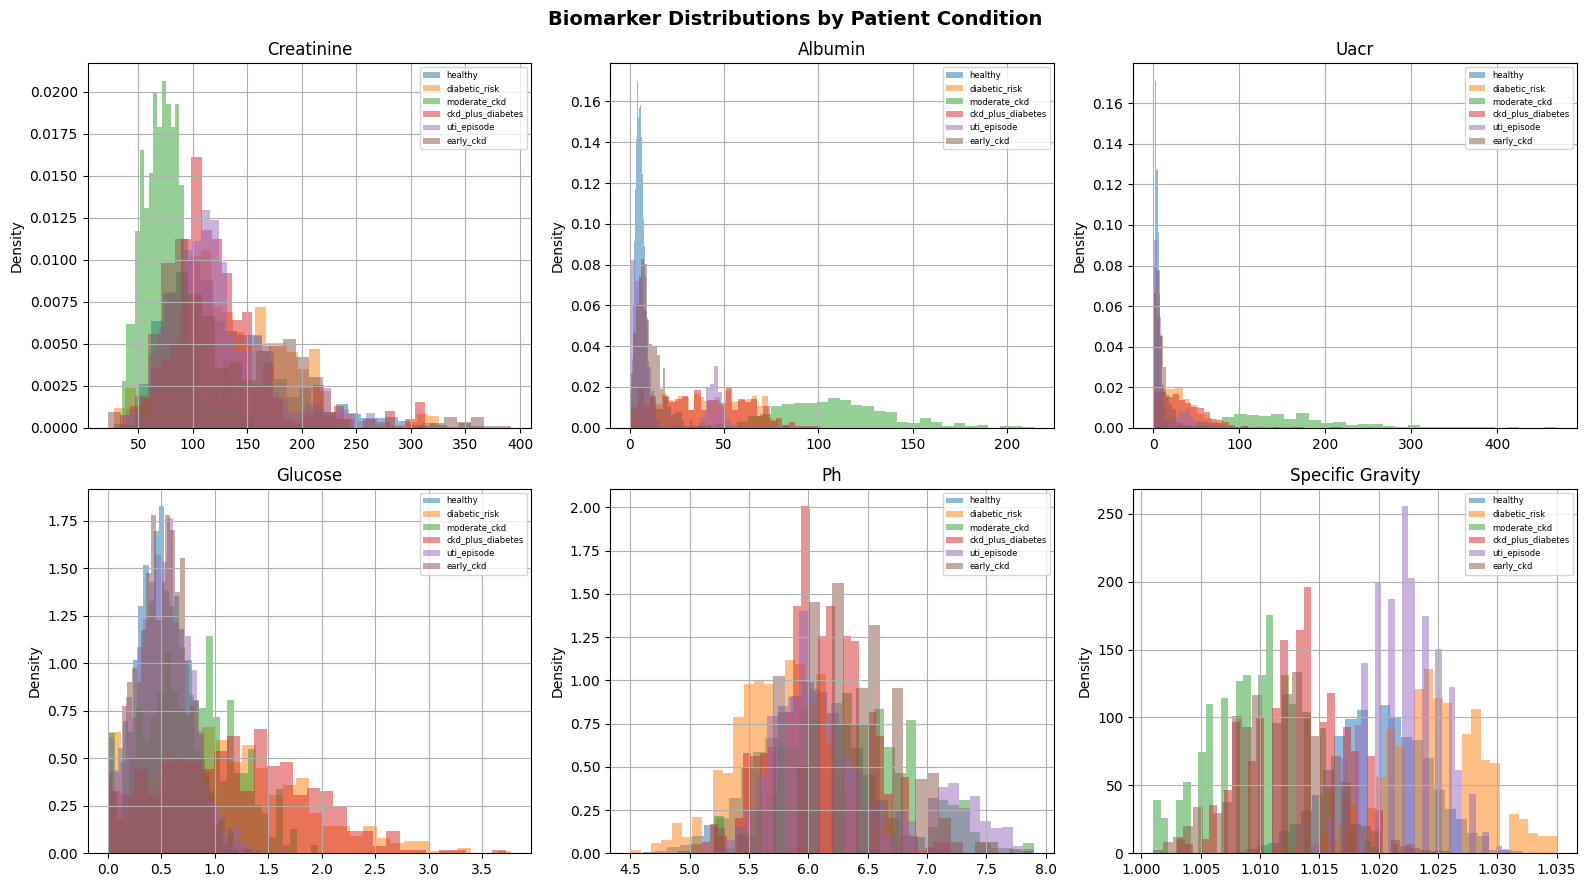

✓ Chart 1 saved


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Biomarker Distributions by Patient Condition', fontsize=14, fontweight='bold')

params  = ['creatinine','albumin','uacr','glucose','ph','specific_gravity']
colours = ['#2196F3','#E91E63','#FF9800','#9C27B0','#4CAF50','#00BCD4']

for ax, param, colour in zip(axes.flatten(), params, colours):
    for cond in df['condition'].unique():
        subset = df[df['condition'] == cond][param]
        subset.hist(ax=ax, bins=30, alpha=0.5, label=cond, density=True)
    ax.set_title(param.replace('_',' ').title())
    ax.legend(fontsize=6)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('charts/01_biomarker_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 1 saved')

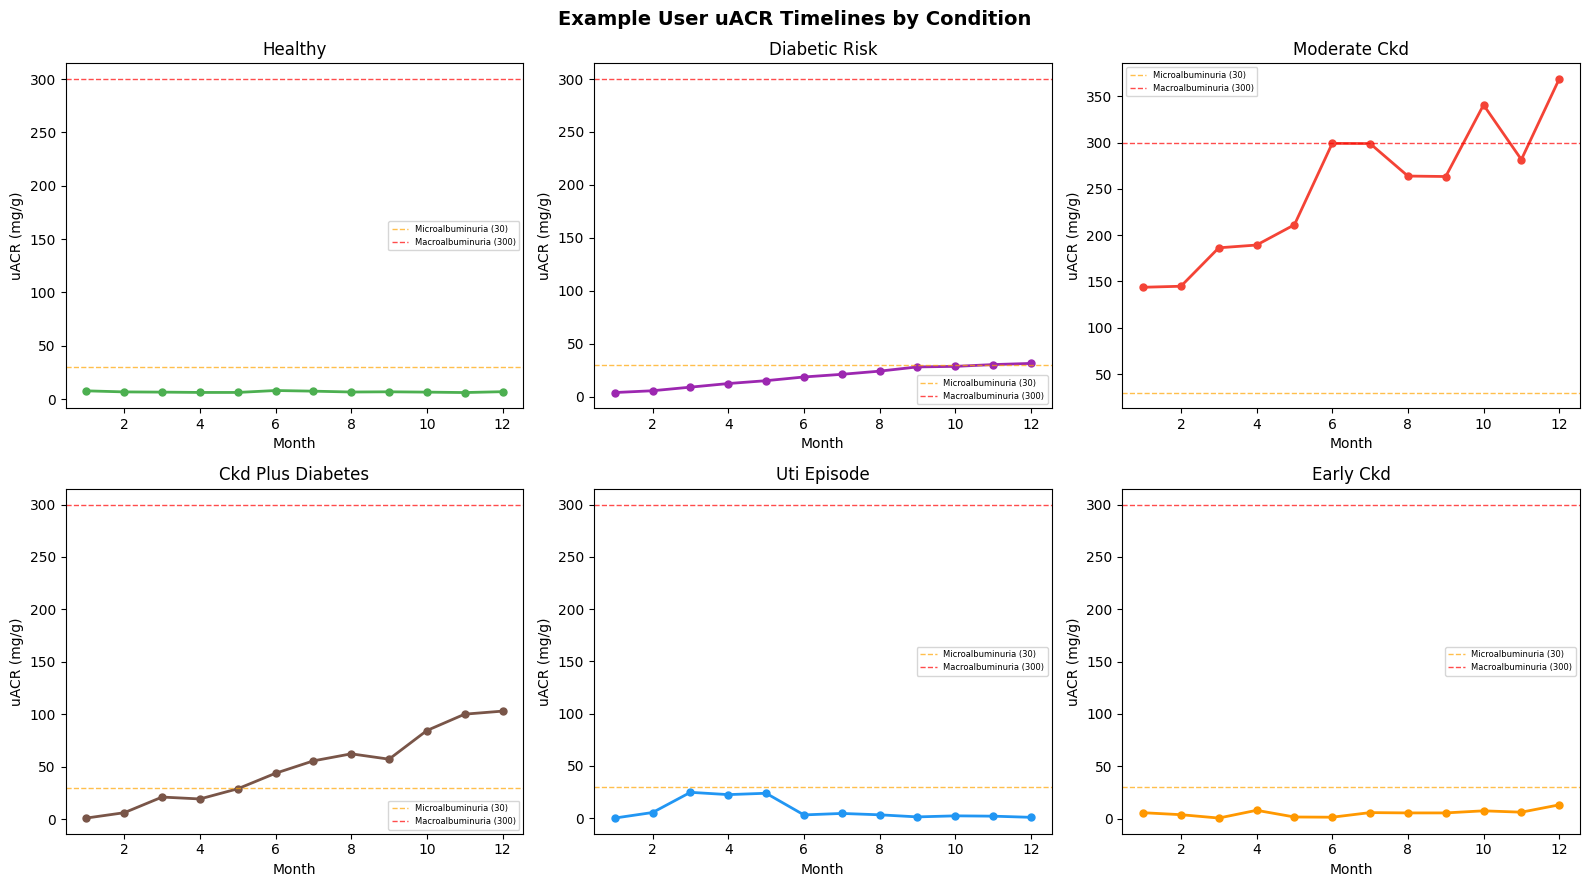

✓ Chart 2 saved


In [23]:
# Plot example timelines — one user per condition
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Example User uACR Timelines by Condition', fontsize=14, fontweight='bold')

cond_color = {
    'healthy':'#4CAF50','early_ckd':'#FF9800','moderate_ckd':'#F44336',
    'uti_episode':'#2196F3','diabetic_risk':'#9C27B0','ckd_plus_diabetes':'#795548'
}

for ax, cond in zip(axes.flatten(), df['condition'].unique()):
    user = df[df['condition']==cond]['user_id'].iloc[0]
    user_df = df[df['user_id']==user].sort_values('month')
    ax.plot(user_df['month'], user_df['uacr'], 'o-',
            color=cond_color.get(cond,'grey'), linewidth=2, markersize=5)
    ax.axhline(y=30,  color='orange', linestyle='--', alpha=0.7, linewidth=1, label='Microalbuminuria (30)')
    ax.axhline(y=300, color='red',    linestyle='--', alpha=0.7, linewidth=1, label='Macroalbuminuria (300)')
    ax.set_title(cond.replace('_',' ').title())
    ax.set_xlabel('Month'); ax.set_ylabel('uACR (mg/g)')
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig('charts/02_user_timelines.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 2 saved')

### Model 1: Isolation Forest (Unsupervised Anomaly Detection)

In [24]:
FEATURES = ['creatinine','albumin','glucose','ph','specific_gravity']

X_all    = df[FEATURES].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.18,   # calibrated against known synthetic anomaly rate;
                       # would need re-tuning against real prevalence data in production
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)
df['anomaly'] = (iso.predict(X_scaled) == -1).astype(int)

print('Anomaly detection rate by condition:')
print('(Higher = better for sick conditions, lower = better for healthy)')
print()
rates = df.groupby('condition')['anomaly'].mean().sort_values(ascending=False)
for cond, rate in rates.items():
    bar = '█' * int(rate * 40)
    marker = '✅' if (cond == 'healthy' and rate < 0.05) or (cond != 'healthy' and rate > 0.15) else '⚠️'
    print(f'  {marker} {cond:<22} {bar} {rate:.1%}')

joblib.dump(iso, 'models/isolation_forest.pkl')
print()
print('✓ Isolation Forest saved')

Anomaly detection rate by condition:
(Higher = better for sick conditions, lower = better for healthy)

  ✅ moderate_ckd           ████████████████████████████████████ 91.4%
  ✅ diabetic_risk          ██████████████████ 47.2%
  ✅ ckd_plus_diabetes      ██████████████ 35.7%
  ⚠️ uti_episode            █████ 12.5%
  ⚠️ early_ckd              ████ 12.3%
  ✅ healthy                █ 3.0%

✓ Isolation Forest saved


### Model 2: Random Forest Risk Classifier

In [25]:
X = df[FEATURES].values
y = df['risk_level'].values

scaler_clf = StandardScaler()
X_s = scaler_clf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_s, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred,
    target_names=['Low Risk','Medium Risk','High Risk'], labels=[0,1,2]))

cv = cross_val_score(clf, X_s, y, cv=5)
print(f'5-fold CV Accuracy: {cv.mean():.3f} ± {cv.std():.3f}')
print()
print('Feature Importances (what drives risk prediction):')
imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
for feat, score in imp.items():
    bar = '█' * int(score * 60)
    print(f'  {feat:<22} {bar} {score:.3f}')

joblib.dump(clf,        'models/risk_classifier.pkl')
joblib.dump(scaler_clf, 'models/scaler.pkl')
print()
print('✓ Risk Classifier and Scaler saved')

=== Classification Report ===
              precision    recall  f1-score   support

    Low Risk       0.99      1.00      0.99       979
 Medium Risk       0.98      0.95      0.96       213
   High Risk       1.00      0.75      0.86         8

    accuracy                           0.99      1200
   macro avg       0.99      0.90      0.94      1200
weighted avg       0.99      0.99      0.99      1200

5-fold CV Accuracy: 0.989 ± 0.005

Feature Importances (what drives risk prediction):
  albumin                ██████████████████████████████ 0.508
  creatinine             ██████████ 0.169
  ph                     ████████ 0.135
  specific_gravity       ███████ 0.132
  glucose                ███ 0.057

✓ Risk Classifier and Scaler saved


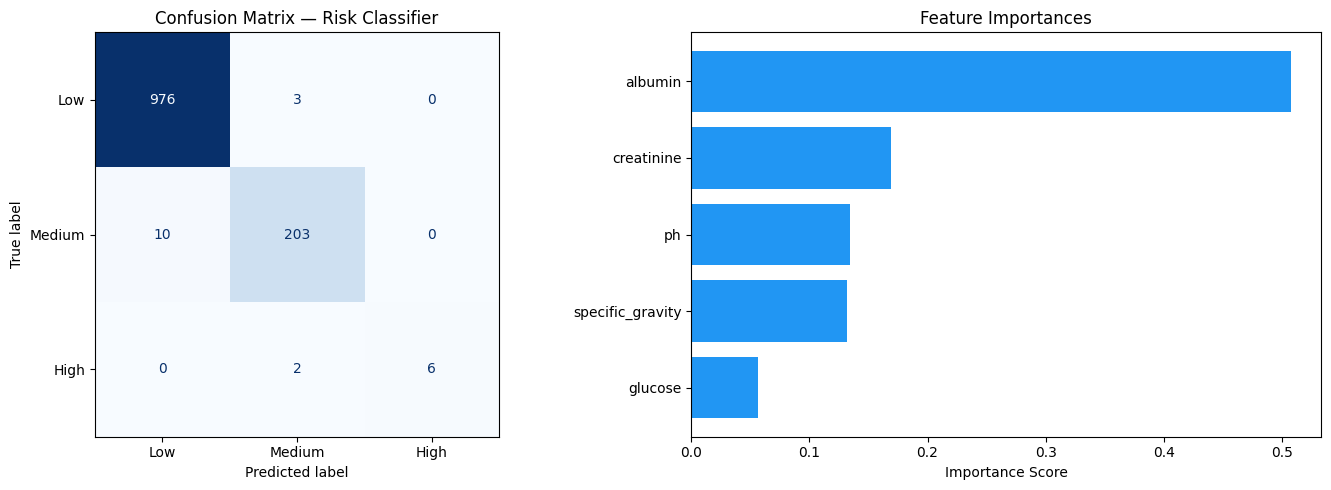

✓ Chart 3 saved


In [26]:
# Confusion Matrix + Feature Importance chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
ConfusionMatrixDisplay(cm, display_labels=['Low','Medium','High']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Risk Classifier')

imp_sorted = imp.sort_values()
axes[1].barh(imp_sorted.index, imp_sorted.values, color='#2196F3')
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('charts/03_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 3 saved')

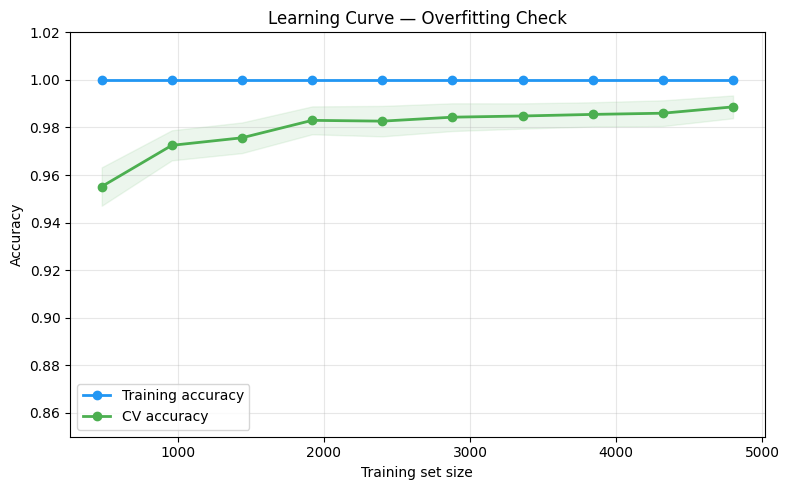

Average train-validation gap: 0.0202

✅ No overfitting detected.
   Train and CV curves are close — model generalises well within this dataset.
   Note: High accuracy reflects rule-based synthetic labels, not noise memorisation.
   Real-world generalisation requires validation on actual Neodocs user data.


In [27]:
# ── Step 5b: Overfitting Check — Learning Curve ──
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    clf, X_s, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1),
         'o-', label='Training accuracy', color='#2196F3', linewidth=2)
plt.plot(train_sizes, val_scores.mean(axis=1),
         'o-', label='CV accuracy', color='#4CAF50', linewidth=2)
plt.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.1, color='#2196F3')
plt.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.1, color='#4CAF50')

plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Overfitting Check')
plt.legend(fontsize=10)
plt.ylim(0.85, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/05_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

gap = train_scores.mean() - val_scores.mean()
print(f'Average train-validation gap: {gap:.4f}')
print()
if gap < 0.03:
    print('✅ No overfitting detected.')
    print('   Train and CV curves are close — model generalises well within this dataset.')
    print('   Note: High accuracy reflects rule-based synthetic labels, not noise memorisation.')
    print('   Real-world generalisation requires validation on actual Neodocs user data.')
else:
    print('⚠️  Possible overfitting — gap exceeds 2%.')
    print('   Consider reducing n_estimators or adding max_depth limit.')

### Sliding Window Anomaly Detection
 This sliding window approach compares every 3-month window to the user's *personal baseline* (first 2 months), catching spikes even if they fully resolve.

In [28]:
def sliding_window_alert(user_df, col, window=3, z_thresh=2.0, baseline_months=2):
    """
    Detects acute episodes by comparing rolling windows to personal baseline.

    Args:
        user_df: DataFrame for one user, sorted by month
        col: biomarker column to analyse
        window: number of months per window (default 3)
        z_thresh: z-score threshold to flag (default 2.0 = 2 std devs)
        baseline_months: how many early months define 'normal' for this user

    Returns:
        List of flagged windows with month range, z-score, and direction
    """
    vals = user_df.sort_values('month')[col].values
    if len(vals) < baseline_months + window:
        return []

    # Personal baseline: first N months BEFORE any episode
    baseline_mean = np.mean(vals[:baseline_months])
    baseline_std  = np.std(vals) + 1e-6   # std of full series for sensitivity

    alerts = []
    for i in range(len(vals) - window + 1):
        window_mean = np.mean(vals[i:i+window])
        z_score     = abs(window_mean - baseline_mean) / baseline_std

        if z_score > z_thresh:
            alerts.append({
                'months':    f'{i+1}–{i+window}',
                'z_score':   round(z_score, 2),
                'direction': 'HIGH ↑' if window_mean > baseline_mean else 'LOW ↓',
                'window_mean': round(window_mean, 2),
                'baseline':    round(baseline_mean, 2)
            })
    return alerts


# ── Test on all condition types ──
print('=== Sliding Window Alerts — Test Across All Conditions ===\n')
test_cases = {
    'healthy':           df[df['condition']=='healthy']['user_id'].iloc[0],
    'early_ckd':         df[df['condition']=='early_ckd']['user_id'].iloc[0],
    'moderate_ckd':      df[df['condition']=='moderate_ckd']['user_id'].iloc[0],
    'uti_episode':       df[df['condition']=='uti_episode']['user_id'].iloc[0],
    'diabetic_risk':     df[df['condition']=='diabetic_risk']['user_id'].iloc[0],
    'ckd_plus_diabetes': df[df['condition']=='ckd_plus_diabetes']['user_id'].iloc[0],
}

for cond, uid in test_cases.items():
    user_df = df[df['user_id']==uid].sort_values('month')
    alerts  = sliding_window_alert(user_df, 'albumin', baseline_months=2)
    ph_alerts = sliding_window_alert(user_df, 'ph', baseline_months=2, z_thresh=1.5)
    print(f'User {uid} ({cond}):')
    print(f'  Albumin alerts: {alerts if alerts else "None — stable"}')
    if ph_alerts:
        print(f'  pH alerts:      {ph_alerts}')
    print()

=== Sliding Window Alerts — Test Across All Conditions ===

User U0000 (healthy):
  Albumin alerts: None — stable
  pH alerts:      [{'months': '8–10', 'z_score': np.float64(1.9), 'direction': 'HIGH ↑', 'window_mean': np.float64(6.07), 'baseline': np.float64(5.5)}, {'months': '9–11', 'z_score': np.float64(2.13), 'direction': 'HIGH ↑', 'window_mean': np.float64(6.13), 'baseline': np.float64(5.5)}]

User U0018 (early_ckd):
  Albumin alerts: None — stable

User U0002 (moderate_ckd):
  Albumin alerts: [{'months': '7–9', 'z_score': np.float64(2.03), 'direction': 'HIGH ↑', 'window_mean': np.float64(118.04), 'baseline': np.float64(79.35)}, {'months': '8–10', 'z_score': np.float64(2.45), 'direction': 'HIGH ↑', 'window_mean': np.float64(125.97), 'baseline': np.float64(79.35)}, {'months': '9–11', 'z_score': np.float64(2.76), 'direction': 'HIGH ↑', 'window_mean': np.float64(131.85), 'baseline': np.float64(79.35)}, {'months': '10–12', 'z_score': np.float64(2.86), 'direction': 'HIGH ↑', 'window_mea

### Personal Baseline Risk Scoring

In [29]:
def personal_baseline_score(user_df, col='uacr'):
    """
    Compares each reading to the user's OWN first 3-month baseline.
    This is more clinically relevant than population thresholds —
    someone with naturally high creatinine shouldn't be penalised.

    Returns z-scores: how far each reading deviates from personal normal.
    """
    user_df  = user_df.sort_values('month')
    vals     = user_df[col].values
    baseline = vals[:3]
    b_mean   = np.mean(baseline)
    b_std    = np.std(baseline) + 1e-6

    z_scores = [(v - b_mean) / b_std for v in vals]
    return z_scores, b_mean


# Generate personal risk summary for all users
def summarise_user(group):
    group  = group.sort_values('month')
    uacr_z, uacr_base = personal_baseline_score(group, 'uacr')
    alb_z,  _         = personal_baseline_score(group, 'albumin')

    # Trend direction using linear slope
    months = np.arange(len(group))
    uacr_slope = np.polyfit(months, group['uacr'].values, 1)[0]
    alb_slope  = np.polyfit(months, group['albumin'].values, 1)[0]

    def slope_to_trend(slope, baseline):
        pct = slope / (baseline + 1e-6) * 100
        if   pct >  5: return 'rising'
        elif pct < -5: return 'falling'
        else:          return 'stable'

    alb_base = group['albumin'].values[:3].mean()

    return pd.Series({
        'condition':         group['condition'].iloc[0],
        'age':               group['age'].iloc[0],
        'gender':            group['gender'].iloc[0],
        'uacr_trend':        slope_to_trend(uacr_slope, uacr_base),
        'albumin_trend':     slope_to_trend(alb_slope,  alb_base),
        'max_personal_z':    round(max(abs(z) for z in uacr_z), 2),
        'latest_uacr':       round(group['uacr'].iloc[-1], 1),
        'latest_risk':       group['risk_label'].iloc[-1],
        'months_of_data':    len(group),
    })

user_summary = df.groupby('user_id').apply(summarise_user).reset_index()

print(f'User summary: {user_summary.shape}')
print()
print('uACR trend by condition (personal baseline):')
print(pd.crosstab(user_summary['condition'], user_summary['uacr_trend']))
print()
print('Average personal z-score by condition (higher = more deviation from own baseline):')
print(user_summary.groupby('condition')['max_personal_z'].mean().sort_values(ascending=False).round(2))

User summary: (500, 10)

uACR trend by condition (personal baseline):
uacr_trend         falling  rising  stable
condition                                 
ckd_plus_diabetes        0      35       0
diabetic_risk            0      50       0
early_ckd                0      74       0
healthy                  0       4     223
moderate_ckd             0      29       1
uti_episode             84       0       0

Average personal z-score by condition (higher = more deviation from own baseline):
condition
moderate_ckd         16.31
early_ckd            15.63
ckd_plus_diabetes    15.40
diabetic_risk        11.98
healthy               4.51
uti_episode           1.60
Name: max_personal_z, dtype: float64


### Alert Generator (The Insight Layer)

In [30]:
def generate_alerts(user_df, user_id):
    user_df = user_df.sort_values('month')
    latest  = user_df.iloc[-1]
    alerts  = []

    # ── Step 1: Determine user's overall albumin trend ──
    # This prevents false positives on healthy users with noisy readings
    alb_vals  = user_df['albumin'].values
    alb_slope = np.polyfit(np.arange(len(alb_vals)), alb_vals, 1)[0]
    pct_change = alb_slope / (alb_vals[0] + 1e-6) * 100

    # Only use lower threshold (1.5) if the overall trend is rising
    # Use stricter threshold (2.0) if trend is flat — avoids healthy false positives
    alb_z_thresh = 1.5 if pct_change > 5 else 2.0

    # ── Step 2: KDIGO population thresholds ──
    if latest['uacr'] >= 300:
        alerts.append({'severity':'HIGH','icon':'🔴',
            'message': f'uACR is {latest["uacr"]:.0f} mg/g — macroalbuminuria. Consult a nephrologist immediately.'})
    elif latest['uacr'] >= 30:
        alerts.append({'severity':'MEDIUM','icon':'🟡',
            'message': f'uACR is {latest["uacr"]:.0f} mg/g — microalbuminuria range. Monitor monthly and consult a doctor.'})

    # ── Step 3: Sliding window with adaptive threshold ──
    alb_alerts = sliding_window_alert(user_df, 'albumin',
        baseline_months=2, z_thresh=alb_z_thresh)

    if alb_alerts:
        worst = max(alb_alerts, key=lambda x: x['z_score'])
        # Check if pH was elevated during the spike window (not just latest month)
        spike_months = user_df[
            (user_df['month'] >= 3) & (user_df['month'] <= 5)
        ]['ph'].mean()

        if spike_months > 6.8:   # elevated pH during spike window
            alerts.append({'severity':'MEDIUM','icon':'🟡',
                'message': f'Albumin spike in months {worst["months"]} with elevated pH — strongly suggests a UTI episode. Monitor for symptoms.'})
        else:
            alerts.append({'severity':'MEDIUM','icon':'🟡',
                'message': f'Albumin steadily rising — months {worst["months"]} (z={worst["z_score"]:.2f}). May indicate early kidney stress. Monitor monthly.'})

    # ── Step 4: Glucose (strict threshold to avoid noise) ──
    glu_alerts = sliding_window_alert(user_df, 'glucose',
        z_thresh=2.5, baseline_months=2)
    if glu_alerts:
        alerts.append({'severity':'MEDIUM','icon':'🟡',
            'message': 'Urine glucose rising consistently. Consider an HbA1c blood test.'})

    if not alerts:
        alerts.append({'severity':'OK','icon':'🟢',
            'message': 'All biomarkers stable. Keep up your health routine!'})

    return alerts

    # ── Test on all 6 archetypes ──
print('=== Generated Alerts Per User Archetype ===\n')

test_cases = {
    'healthy':           df[df['condition']=='healthy']['user_id'].iloc[0],
    'early_ckd':         df[df['condition']=='early_ckd']['user_id'].iloc[0],
    'moderate_ckd':      df[df['condition']=='moderate_ckd']['user_id'].iloc[0],
    'uti_episode':       df[df['condition']=='uti_episode']['user_id'].iloc[0],
    'diabetic_risk':     df[df['condition']=='diabetic_risk']['user_id'].iloc[0],
    'ckd_plus_diabetes': df[df['condition']=='ckd_plus_diabetes']['user_id'].iloc[0],
}

for cond, uid in test_cases.items():
    user_df = df[df['user_id'] == uid]
    alerts  = generate_alerts(user_df, uid)
    print(f'User {uid} ({cond.replace("_"," ").title()}):')
    for a in alerts:
        print(f'  {a["icon"]} [{a["severity"]}] {a["message"]}')
    print()

=== Generated Alerts Per User Archetype ===

User U0000 (Healthy):
  🟢 [OK] All biomarkers stable. Keep up your health routine!

User U0018 (Early Ckd):
  🟢 [OK] All biomarkers stable. Keep up your health routine!

User U0002 (Moderate Ckd):
  🔴 [HIGH] uACR is 369 mg/g — macroalbuminuria. Consult a nephrologist immediately.
  🟡 [MEDIUM] Albumin steadily rising — months 10–12 (z=2.86). May indicate early kidney stress. Monitor monthly.

User U0016 (Uti Episode):
  🟡 [MEDIUM] Albumin spike in months 3–5 with elevated pH — strongly suggests a UTI episode. Monitor for symptoms.

User U0001 (Diabetic Risk):
  🟡 [MEDIUM] uACR is 32 mg/g — microalbuminuria range. Monitor monthly and consult a doctor.
  🟡 [MEDIUM] Albumin steadily rising — months 10–12 (z=2.74). May indicate early kidney stress. Monitor monthly.

User U0003 (Ckd Plus Diabetes):
  🟡 [MEDIUM] uACR is 103 mg/g — microalbuminuria range. Monitor monthly and consult a doctor.
  🟡 [MEDIUM] Albumin steadily rising — months 10–12 (z=2.

### Charts Results

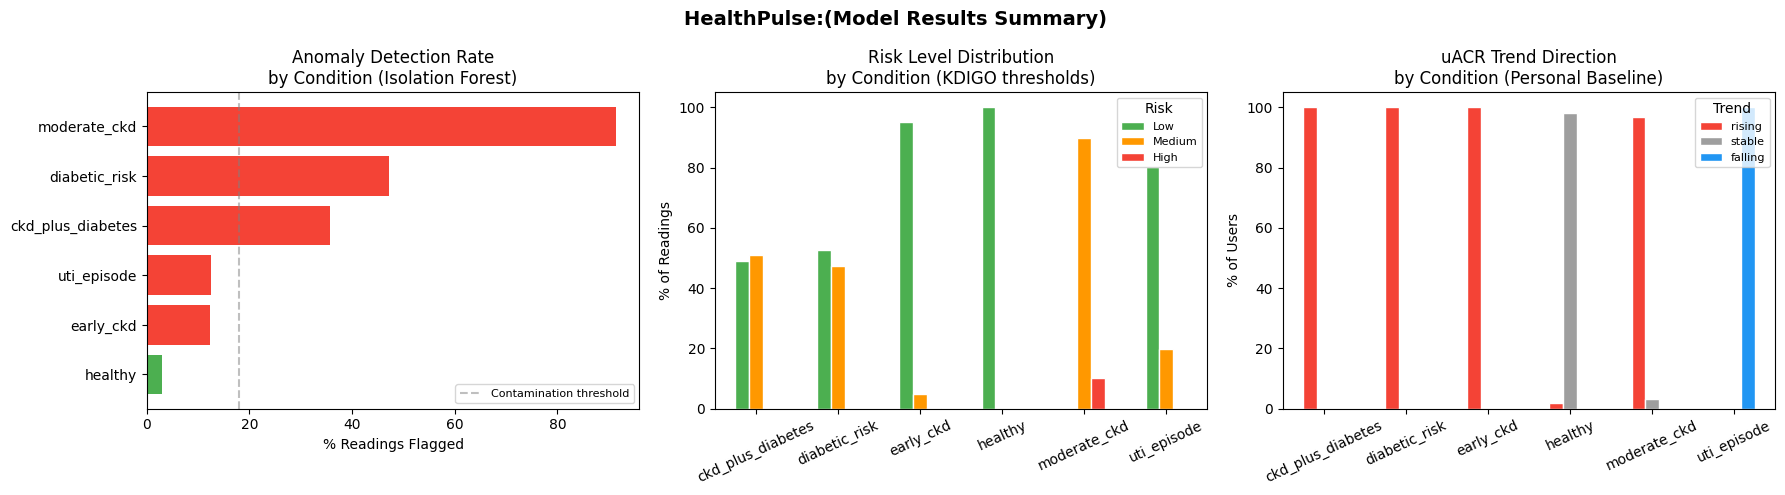

✓ Chart 4 saved — this is your main presentation chart


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HealthPulse:(Model Results Summary)', fontsize=14, fontweight='bold')

# Chart 1: Anomaly rate
rates = df.groupby('condition')['anomaly'].mean().sort_values()
colours_bar = ['#4CAF50' if c=='healthy' else '#F44336' for c in rates.index]
axes[0].barh(rates.index, rates.values*100, color=colours_bar)
axes[0].set_title('Anomaly Detection Rate\nby Condition (Isolation Forest)')
axes[0].set_xlabel('% Readings Flagged')
axes[0].axvline(x=18, color='grey', linestyle='--', alpha=0.5, label='Contamination threshold')
axes[0].legend(fontsize=8)

# Chart 2: Risk distribution
risk_by_cond = pd.crosstab(df['condition'], df['risk_label'], normalize='index') * 100
for col in ['Low','Medium','High']:
    if col not in risk_by_cond.columns:
        risk_by_cond[col] = 0
risk_by_cond[['Low','Medium','High']].plot(
    kind='bar', ax=axes[1],
    color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[1].set_title('Risk Level Distribution\nby Condition (KDIGO thresholds)')
axes[1].set_xlabel(''); axes[1].set_ylabel('% of Readings')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Risk', fontsize=8)

# Chart 3: uACR trend
trend_counts = pd.crosstab(
    user_summary['condition'], user_summary['uacr_trend'], normalize='index') * 100
for col in ['rising','stable','falling']:
    if col not in trend_counts.columns:
        trend_counts[col] = 0
trend_counts[['rising','stable','falling']].plot(
    kind='bar', ax=axes[2],
    color=['#F44336','#9E9E9E','#2196F3'], edgecolor='white')
axes[2].set_title('uACR Trend Direction\nby Condition (Personal Baseline)')
axes[2].set_xlabel(''); axes[2].set_ylabel('% of Users')
axes[2].tick_params(axis='x', rotation=25)
axes[2].legend(title='Trend', fontsize=8)

plt.tight_layout()
plt.savefig('charts/04_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 4 saved — this is your main presentation chart')

In [32]:
# Save datasets
df.to_csv('healthpulse_dataset.csv', index=False)
user_summary.to_csv('user_summary.csv', index=False)

# Verify all files
all_files = {
    'models/risk_classifier.pkl':     'Risk Classifier',
    'models/scaler.pkl':              'StandardScaler',
    'models/isolation_forest.pkl':    'Isolation Forest',
    'healthpulse_dataset.csv':        'Full 6000-row dataset',
    'user_summary.csv':               'Per-user trend summary',
    'charts/01_biomarker_distributions.png': 'EDA chart',
    'charts/02_user_timelines.png':          'User timelines',
    'charts/03_model_evaluation.png':        'Model evaluation',
    'charts/04_results_summary.png':         'Main results chart',
}

print('=== Files Generated ===')
all_ok = True
for path, desc in all_files.items():
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1024:.1f} KB' if exists else ''
    status = '✓' if exists else '✗ MISSING'
    if not exists: all_ok = False
    print(f'  {status}  {path:<48} {size:<10} {desc}')

print()
if all_ok:
    print('✅ All files saved successfully. Next step: Build the Streamlit dashboard.')
else:
    print('⚠️  Some files missing — re-run the relevant cells.')

=== Files Generated ===
  ✓  models/risk_classifier.pkl                       3715.4 KB  Risk Classifier
  ✓  models/scaler.pkl                                0.7 KB     StandardScaler
  ✓  models/isolation_forest.pkl                      2180.5 KB  Isolation Forest
  ✓  healthpulse_dataset.csv                          366.0 KB   Full 6000-row dataset
  ✓  user_summary.csv                                 26.1 KB    Per-user trend summary
  ✓  charts/01_biomarker_distributions.png            152.8 KB   EDA chart
  ✓  charts/02_user_timelines.png                     159.5 KB   User timelines
  ✓  charts/03_model_evaluation.png                   52.7 KB    Model evaluation
  ✓  charts/04_results_summary.png                    125.8 KB   Main results chart

✅ All files saved successfully. Next step: Build the Streamlit dashboard.


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os
import shutil

project_folder = "/content/HealthPulse_Project"

os.makedirs(os.path.join(project_folder, "models"), exist_ok=True)
os.makedirs(os.path.join(project_folder, "charts"), exist_ok=True)

# Copy models
shutil.copy("models/risk_classifier.pkl", project_folder + "/models")
shutil.copy("models/scaler.pkl", project_folder + "/models")
shutil.copy("models/isolation_forest.pkl", project_folder + "/models")

# Copy charts
shutil.copy("charts/01_biomarker_distributions.png", project_folder + "/charts")
shutil.copy("charts/02_user_timelines.png", project_folder + "/charts")
shutil.copy("charts/03_model_evaluation.png", project_folder + "/charts")
shutil.copy("charts/04_results_summary.png", project_folder + "/charts")

# Copy CSVs
shutil.copy("healthpulse_dataset.csv", project_folder)
shutil.copy("user_summary.csv", project_folder)

# Copy the entire folder to Google Drive
drive_folder = "/content/drive/MyDrive/HealthPulse_Project"
if os.path.exists(drive_folder):
    shutil.rmtree(drive_folder)
shutil.copytree(project_folder, drive_folder)

# Create ZIP
shutil.make_archive("HealthPulse_Project", "zip", project_folder)

# Download
from google.colab import files
files.download("HealthPulse_Project.zip")

print("✅ Project saved to Google Drive and ZIP downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Project saved to Google Drive and ZIP downloaded successfully!
